In [99]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [100]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

Линейная регрессия


Линейная регрессия используется для предиктивного анализа. Линейная регрессия — это линейный подход к моделированию взаимосвязи между целевой переменной и множественными предикторами (независимыми переменными). Линейная регрессия фокусируется на условном распределении вероятностей ответа с учетом значений предикторов. При линейной регрессии существует опасность переобучения. Формула линейной регрессии выглядит следующим образом:

y = θx + b

где

θ – веса (параметры) модели

b – смещение.

Это самая простая форма регрессионного анализа, которая используется для моделирования линейной связи между одной зависимой переменной и одной или несколькими независимыми переменными.

In [101]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes  # подключаем датасет из sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [102]:

# Присвоим переменной «url» ссылку на датасет:

url = '/content/global_cars_dataset_synthetic.csv'


dataset = pd.read_csv(url, names = cols)

In [103]:
dataset.head(10)

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
1,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA
2,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA
3,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China
4,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA
5,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK
6,CAR_0006,Tesla,2012,Coupe,Diesel,Automatic,2124,321,19,63134,UK
7,CAR_0007,Audi,2011,Hatchback,Petrol,Automatic,4527,342,29,74241,Japan
8,CAR_0008,Tesla,2016,SUV,Diesel,Automatic,1729,309,20,54364,China
9,CAR_0009,Audi,2017,Hatchback,Hybrid,Manual,1561,470,12,65750,Germany


In [104]:
# загружаем данные в pandas dataframe

dataset["DP"] = dataset['Manufacture_Year']
dataset

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,DP
0,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Manufacture_Year
1,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,2006
2,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,2023
3,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,2007
4,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,2013
...,...,...,...,...,...,...,...,...,...,...,...,...
296,CAR_0296,Audi,2015,Pickup,Hybrid,Automatic,3572,137,30,74301,Germany,2015
297,CAR_0297,Ford,2023,Hatchback,Petrol,Manual,4348,342,21,97523,USA,2023
298,CAR_0298,Mercedes,2020,SUV,Electric,Automatic,3538,151,10,66351,Japan,2020
299,CAR_0299,Ford,2023,Coupe,Diesel,Manual,3954,442,10,85653,Germany,2023


In [105]:
dataset.drop('Manufacture_Year', axis=1, inplace=True)

In [106]:

from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dataset[[ 'Car_ID', 'Brand', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country', 'DP']] = enc.fit_transform(dataset[[ 'Car_ID', 'Brand', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country','DP']])
dataset.head()

,Car_ID,Brand,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,DP
0,300.0,2.0,0.0,2.0,2.0,287.0,220.0,21.0,300.0,3.0,21.0
1,0.0,7.0,4.0,4.0,1.0,225.0,185.0,7.0,227.0,6.0,1.0
2,1.0,8.0,1.0,4.0,0.0,257.0,29.0,15.0,251.0,6.0,18.0
3,2.0,8.0,2.0,0.0,1.0,47.0,5.0,6.0,239.0,0.0,2.0
4,3.0,8.0,1.0,4.0,1.0,52.0,117.0,6.0,158.0,6.0,8.0


In [107]:
X = dataset.drop(['DP'], axis=1)
y = dataset['DP']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (301, 10) | y shape: (301,) 


In [108]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [109]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [110]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)


RMSE:  5.7906
  R2: -0.0384
 Adjusted R2: -0.2461
 Cross Validated R2: -0.1167


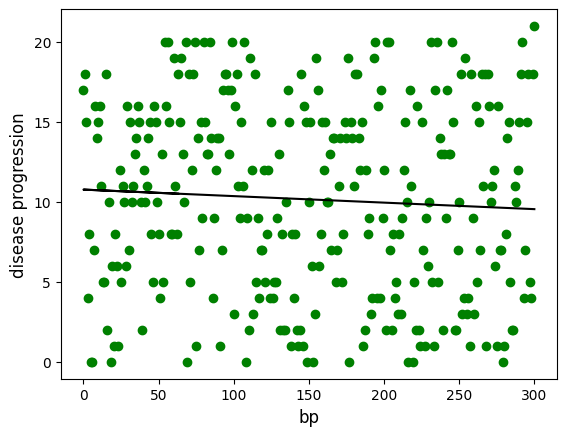

In [111]:
# попробуем отрисовать, как выглядит наша линейная регрессия

X2 = dataset['Price_USD'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = dataset['DP'].values


model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(X2),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('bp', size=12)
plt.show()

Полиномиальная регрессия

In [112]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [113]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  37.231
  R2: -48.1656
 Adjusted R2: 23.6918
 Cross Validated R2: -46.0858


значения представляют собой метрики оценки регрессионной модели. модель не нашла никакой связи.

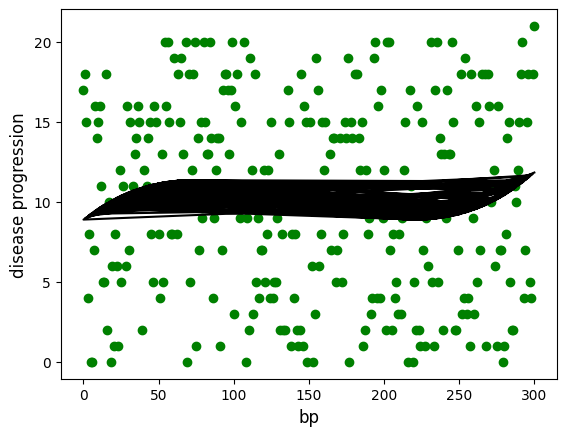

In [114]:
X2 = dataset['Price_USD'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = dataset['DP'].values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)


plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('bp', size=12)
plt.show()

Регрессия дерева принятия решений


Дерево решений является самым мощным и популярным инструментом для классификации и прогнозирования. Дерево принятия решений представляет собой древовидную структуру, похожую на блок-схему, где каждый внутренний узел обозначает тест по атрибуту, каждая ветвь представляет результат теста, а каждый конечный узел (терминальный узел) содержит метку класса. Существует непараметрический метод, используемый для моделирования дерева решений для прогнозирования непрерывного результата.

In [115]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [116]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  8.1371
  R2: -1.0505
 Adjusted R2: -1.4606
 Cross Validated R2: -1.2446


регресия дерева справилась лучше, но она не пригодна изходя из значений

Регрессия случайного леса

In [117]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  5.7642
  R2: -0.029
 Adjusted R2: -0.2347
 Cross Validated R2: -0.1474


получаем значения еще лучше, но все равно не то что нужно

Регрессия опорных векторов (SVR)


Регрессия опорных векторов (SVR) — это тип метода опорных векторов (SVM), который используется для задач регрессии. Он пытается найти функцию, которая наилучшим образом предсказывает непрерывное выходное значение для заданного входного значения.

In [118]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  6.2432
  R2: -0.2071
 Adjusted R2: -0.4485
 Cross Validated R2: -0.2025


получаем уже результат
хуже

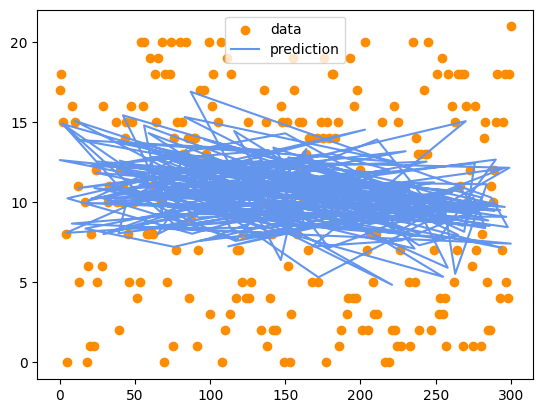

In [119]:
plt.scatter(X_train["Price_USD"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Price_USD"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [120]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  5.8765
  R2: -0.0695
 Adjusted R2: -0.2834
 Cross Validated R2: -0.168


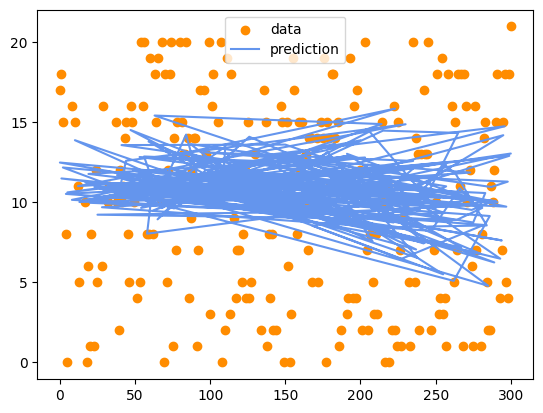

In [122]:
plt.scatter(X_train["Price_USD"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Price_USD"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [123]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  5.7955
  R2: -0.0402
 Adjusted R2: -0.2482
 Cross Validated R2: -0.1095


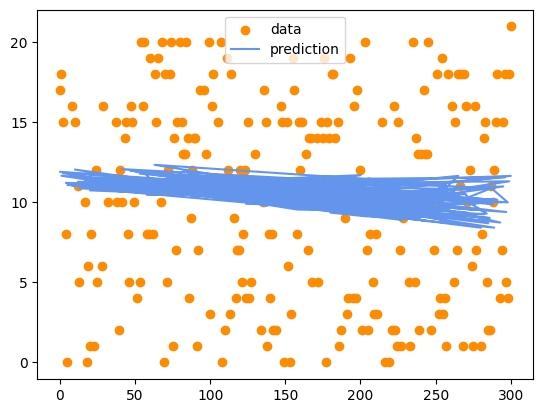

In [125]:
plt.scatter(X_train["Price_USD"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Price_USD"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

Регрессия ElasticNet

Линейная регрессия страдает от переобучения и не может работать с коллинеарными данными. Когда в наборе данных много признаков и даже некоторые из них не имеют отношения к прогностической модели. Это делает модель более сложной из-за слишком неточного прогнозирования на тестовом наборе (или переобучения). Такая модель с высокой дисперсией не обобщает на новых данных. Итак, чтобы решить эти проблемы, мы включили нормировку как L-2, так и L-1, чтобы получить преимущества как Ridge, так и Lasso одновременно. Результирующая модель обладает большей предсказательной силой, чем Лассо. Он выполняет выбор признаков, а также упрощает гипотезу.

In [126]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  5.7522
  R2: -0.0247
 Adjusted R2: -0.2296
 Cross Validated R2: -0.1116


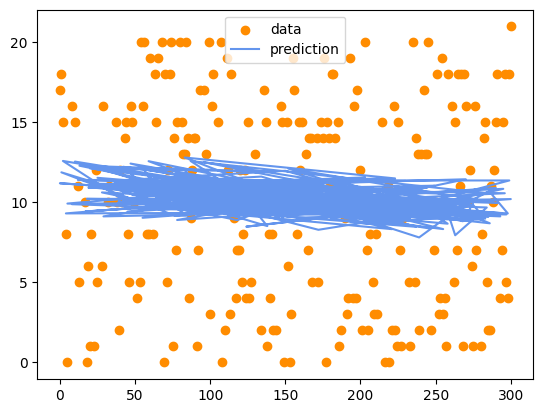

In [128]:
plt.scatter(X_train["Price_USD"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Price_USD"], modelEN.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()